
Processing cnrm


/home/precious/anaconda3/lib/python3.11/site-packages/xarray/backends/plugins.py:80: RuntimeWarning: Engine 'cfradial1' loading failed:
cannot import name 'DataTree' from 'xarray' (/home/precious/anaconda3/lib/python3.11/site-packages/xarray/__init__.py)
  warnings.warn(f"Engine {name!r} loading failed:\n{ex}", RuntimeWarning)
/home/precious/anaconda3/lib/python3.11/site-packages/xarray/backends/plugins.py:80: RuntimeWarning: Engine 'datamet' loading failed:
cannot import name 'DataTree' from 'xarray' (/home/precious/anaconda3/lib/python3.11/site-packages/xarray/__init__.py)
  warnings.warn(f"Engine {name!r} loading failed:\n{ex}", RuntimeWarning)
/home/precious/anaconda3/lib/python3.11/site-packages/xarray/backends/plugins.py:80: RuntimeWarning: Engine 'furuno' loading failed:
cannot import name 'DataTree' from 'xarray' (/home/precious/anaconda3/lib/python3.11/site-packages/xarray/__init__.py)
  warnings.warn(f"Engine {name!r} loading failed:\n{ex}", RuntimeWarning)
/home/precious/ana

Opened cnrm_ctl_emidust.nc with h5netcdf
Opened cnrm_dust_emidust.nc with h5netcdf

Processing gfdl
Opened gfdl_ctl_emidust.nc with h5netcdf
Opened gfdl_dust_emidust.nc with h5netcdf

Processing giss
Opened giss_ctl_emidust.nc with netcdf4
Opened giss_dust_emidust.nc with netcdf4

Processing ipsl
Opened ipsl_ctl_emidust.nc with h5netcdf
Opened ipsl_dust_emidust.nc with h5netcdf

Processing miroc6
Opened miroc6_ctl_emidust.nc with h5netcdf
Opened miroc6_dust_emidust.nc with h5netcdf

Processing mpi
Opened mpi_ctl_emidust.nc with h5netcdf
Opened mpi_dust_emidust.nc with h5netcdf

Processing ukesm
Opened ukesm_ctl_emidust.nc with h5netcdf
Opened ukesm_dust_emidust.nc with h5netcdf

North Africa mean values:
CNRM-ESM2-1: 8.989 Tg yr-1
GFDL-ESM4: 2.525 Tg yr-1
GISS-E2-1-G: 3.280 Tg yr-1
IPSL-CM6A-LR-INCA: 3.779 Tg yr-1
MIROC6: 2.880 Tg yr-1
MPI-ESM-1-2-HAM: 3.171 Tg yr-1
UKESM1-0-LL: 15.620 Tg yr-1
MME: 4.858 Tg yr-1


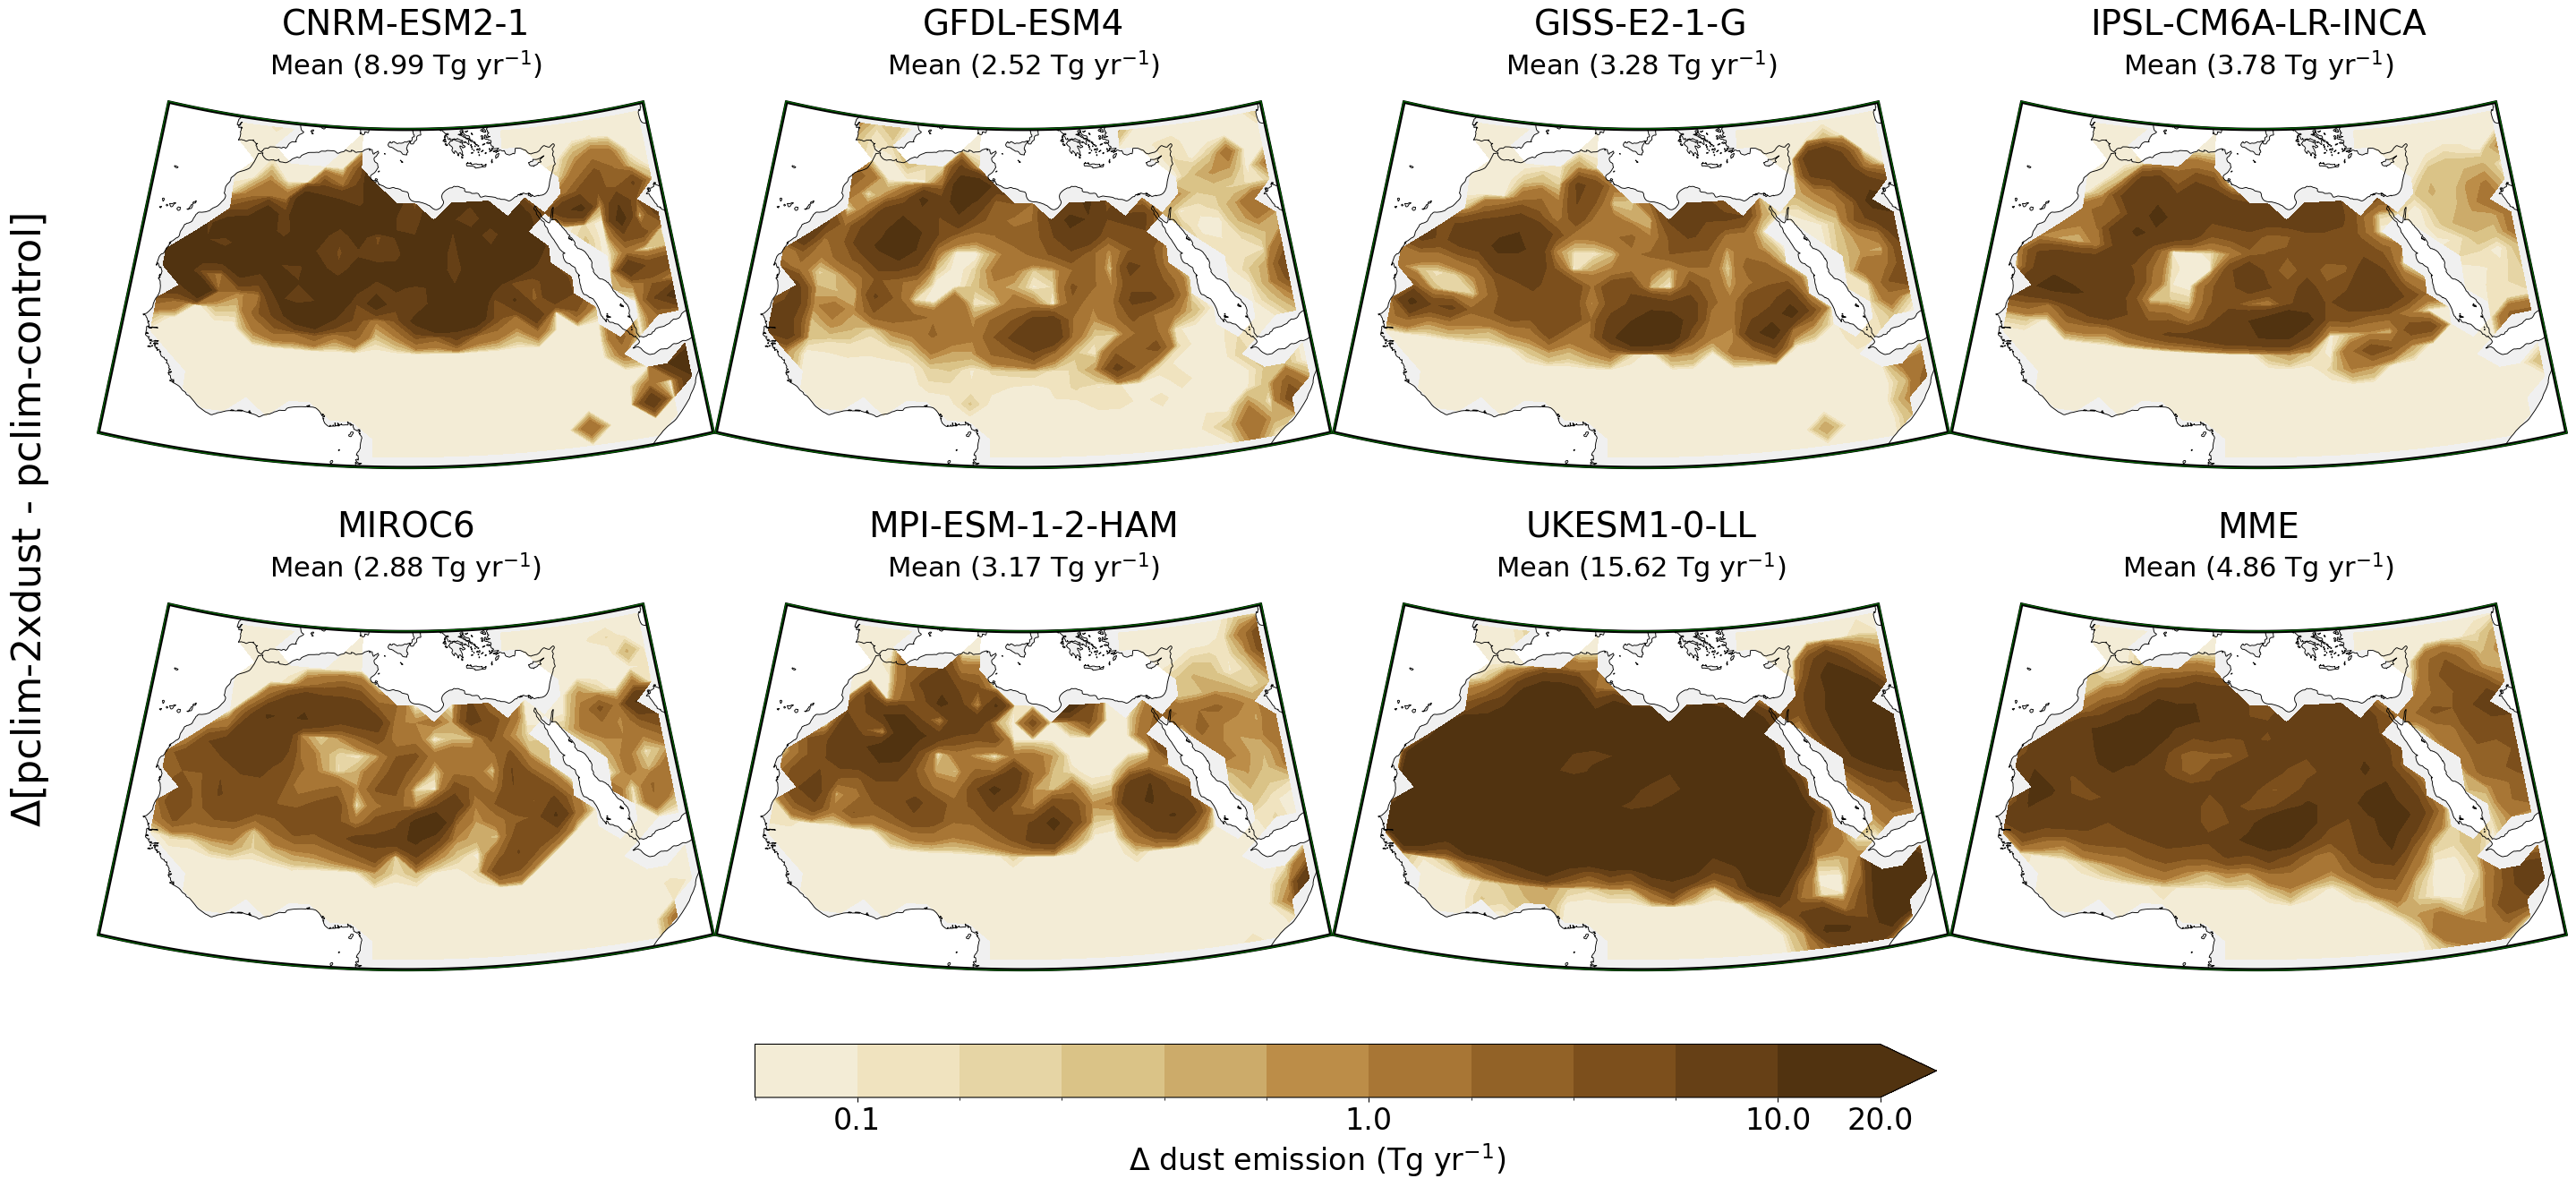

In [1]:
import os
from pathlib import Path

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import ListedColormap
from matplotlib.path import Path as MplPath
from matplotlib.patches import PathPatch

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import regionmask


# ============================================================
# PATH
# ============================================================
DATA_DIR = Path(".")
os.chdir(DATA_DIR)


# ============================================================
# SETTINGS
# ============================================================
models = ["cnrm", "gfdl", "giss", "ipsl", "miroc6", "mpi", "ukesm"]

model_titles = {
    "cnrm": "CNRM-ESM2-1",
    "gfdl": "GFDL-ESM4",
    "giss": "GISS-E2-1-G",
    "ipsl": "IPSL-CM6A-LR-INCA",
    "miroc6": "MIROC6",
    "mpi": "MPI-ESM-1-2-HAM",
    "ukesm": "UKESM1-0-LL",
    "mme": "MME",
}

VAR_NAME = "emidust"

SECONDS_PER_YEAR = 365.0 * 24.0 * 3600.0
KG_TO_TG = 1e-9

# North Africa domain
NA_LON1 = -20
NA_LON2 = 50
NA_LAT1 = 0
NA_LAT2 = 40

# Color levels
# 0.0 is included so low values are colored instead of white.
levels = [0.0, 0.1, 0.2, 0.3, 0.5, 0.75, 1, 2, 3, 5, 10, 20]
VMIN_FOR_MEAN = 0.1

# True  = mean only over values >= 0.1
# False = mean over all North Africa land values
MEAN_ONLY_VISIBLE_VALUES = True

# Optional inner curved Sahel box
DRAW_INNER_BOX = False

INNER_LON0 = -20
INNER_LON1 = 30
INNER_LAT0 = 10
INNER_LAT1 = 20


# ============================================================
# BROWN DUST COLORMAP
# ============================================================
def make_topo15lev_brown_cmap():
    colors = [
        "#f3ecd6",
        "#f0e3bf",
        "#e6d5a5",
        "#dac387",
        "#ccab6a",
        "#bc8d48",
        "#a87635",
        "#926227",
        "#7c4f1c",
        "#664016",
        "#513310",
    ]

    cmap = ListedColormap(colors, name="topo15lev_brown_like")
    cmap.set_under("#f4f1e9")
    cmap.set_over("#513310")
    cmap.set_bad("white")
    return cmap


cmap = make_topo15lev_brown_cmap()

# Do NOT use extend="max" inside BoundaryNorm here.
# contourf/colorbar will handle extend="max".
norm = mcolors.BoundaryNorm(
    boundaries=levels,
    ncolors=cmap.N,
)


# ============================================================
# HELPERS
# ============================================================
def open_dataset_robust(fname, decode_times=True):
    errors = []

    for engine in ["h5netcdf", "netcdf4", "scipy", None]:
        try:
            if engine is None:
                ds = xr.open_dataset(fname, decode_times=decode_times)
            else:
                ds = xr.open_dataset(fname, decode_times=decode_times, engine=engine)

            print(f"Opened {fname} with {engine if engine else 'default'}")
            return ds

        except Exception as e:
            errors.append(f"{engine if engine else 'default'}: {repr(e)}")

    raise RuntimeError(f"Could not open {fname}\n" + "\n".join(errors))


def open_var(fname, var_name=VAR_NAME):
    ds = open_dataset_robust(fname)

    if var_name not in ds.data_vars:
        raise KeyError(
            f"{var_name} not found in {fname}. "
            f"Variables are {list(ds.data_vars)}"
        )

    da = ds[var_name].load()
    ds.close()
    return da


def guess_lon_lat_names(da):
    lon_name, lat_name = None, None

    for name in list(da.dims) + list(da.coords):
        low = name.lower()

        if lon_name is None and low in ["lon", "longitude", "x"]:
            lon_name = name

        if lat_name is None and low in ["lat", "latitude", "y"]:
            lat_name = name

    if lon_name is None or lat_name is None:
        raise ValueError(
            f"Could not identify lon/lat names. "
            f"dims={list(da.dims)}, coords={list(da.coords)}"
        )

    return lon_name, lat_name


def guess_time_name(da):
    for name in da.dims:
        if "time" in name.lower():
            return name
    return None


def standardize_lonlat_names(da):
    lon_name, lat_name = guess_lon_lat_names(da)

    rename_dict = {}

    if lon_name != "lon":
        rename_dict[lon_name] = "lon"

    if lat_name != "lat":
        rename_dict[lat_name] = "lat"

    if rename_dict:
        da = da.rename(rename_dict)

    return da


def shift_lon_to_180(da):
    """
    Convert longitude from 0-360 to -180 to 180 if needed.
    """
    lon_name, _ = guess_lon_lat_names(da)
    lon = da[lon_name]

    if float(lon.max()) > 180:
        da = da.assign_coords({lon_name: (((lon + 180) % 360) - 180)})
        da = da.sortby(lon_name)

    return da


def sort_lat_lon(da):
    da = standardize_lonlat_names(da)

    if "lon" in da.coords:
        da = da.sortby("lon")

    if "lat" in da.coords:
        if np.any(np.diff(da["lat"].values) < 0):
            da = da.sortby("lat")

    return da


def standardize_for_plot_and_mme(da):
    """
    Standardize lon/lat names, longitude convention, and coordinate order.
    
    """
    da = shift_lon_to_180(da)
    da = standardize_lonlat_names(da)
    da = sort_lat_lon(da)
    return da


def compute_gridcell_area(lat, lon):
    """
    Compute grid-cell area [m2] for 1D regular lat/lon grids.
    """
    R = 6_371_000.0

    lat = np.asarray(lat, dtype=float)
    lon = np.asarray(lon, dtype=float)

    lat_rad = np.deg2rad(lat)
    lon_rad = np.deg2rad(lon)

    lat_bnds = np.empty(len(lat) + 1)
    lat_bnds[1:-1] = 0.5 * (lat_rad[:-1] + lat_rad[1:])
    lat_bnds[0] = lat_rad[0] - 0.5 * (lat_rad[1] - lat_rad[0])
    lat_bnds[-1] = lat_rad[-1] + 0.5 * (lat_rad[-1] - lat_rad[-2])

    lon_bnds = np.empty(len(lon) + 1)
    lon_bnds[1:-1] = 0.5 * (lon_rad[:-1] + lon_rad[1:])
    lon_bnds[0] = lon_rad[0] - 0.5 * (lon_rad[1] - lon_rad[0])
    lon_bnds[-1] = lon_rad[-1] + 0.5 * (lon_rad[-1] - lon_rad[-2])

    dlon = np.diff(lon_bnds)

    area = (
        R**2
        * (np.sin(lat_bnds[1:]) - np.sin(lat_bnds[:-1]))[:, None]
        * dlon[None, :]
    )

    return np.abs(area)


def flux_to_tgyr_per_gridcell(da):
    """
    Convert kg m-2 s-1 to Tg yr-1 per grid cell.
    """
    lon_name, lat_name = guess_lon_lat_names(da)

    lat = da[lat_name]
    lon = da[lon_name]

    if lat.ndim != 1 or lon.ndim != 1:
        raise ValueError("This script assumes 1D latitude and longitude.")

    area = compute_gridcell_area(lat.values, lon.values)

    area_da = xr.DataArray(
        area,
        coords={lat_name: lat, lon_name: lon},
        dims=(lat_name, lon_name),
    )

    return da * area_da * SECONDS_PER_YEAR * KG_TO_TG


def make_land_mask(lat, lon):
    """
    Land = True, Ocean = False.
    """
    land = regionmask.defined_regions.natural_earth_v5_0_0.land_110
    mask = land.mask(lon, lat)
    return mask.notnull()


def subset_north_africa(da):
    """
    Shift longitude and subset to North Africa.
    """
    da = shift_lon_to_180(da)

    lon_name, lat_name = guess_lon_lat_names(da)

    lat_vals = da[lat_name].values

    if lat_vals[0] < lat_vals[-1]:
        da = da.sel(
            {
                lon_name: slice(NA_LON1, NA_LON2),
                lat_name: slice(NA_LAT1, NA_LAT2),
            }
        )
    else:
        da = da.sel(
            {
                lon_name: slice(NA_LON1, NA_LON2),
                lat_name: slice(NA_LAT2, NA_LAT1),
            }
        )

    return da



def make_curved_box_path(lon0, lon1, lat0, lat1, amp_top=0.28, amp_bot=0.32, n=200):
    """
    Pinched curved frame.
    """
    f = np.linspace(0, 1, n)

    top = np.column_stack(
        (
            np.linspace(lon0, lon1, n),
            lat1 - amp_top * np.sin(np.pi * f),
        )
    )

    right = np.column_stack(
        (
            [lon1] * n,
            np.linspace(lat1, lat0, n),
        )
    )

    bottom = np.column_stack(
        (
            np.linspace(lon1, lon0, n),
            lat0 - amp_bot * np.sin(np.pi * f),
        )
    )

    left = np.column_stack(
        (
            [lon0] * n,
            np.linspace(lat0, lat1, n),
        )
    )

    pts = np.vstack([top, right, bottom, left, top[:1]])

    codes = (
        [MplPath.MOVETO]
        + [MplPath.LINETO] * (len(pts) - 2)
        + [MplPath.CLOSEPOLY]
    )

    return MplPath(pts, codes)


box_path = make_curved_box_path(
    NA_LON1,
    NA_LON2,
    NA_LAT1,
    NA_LAT2,
    amp_top=0.28,
    amp_bot=0.32,
    n=200,
)


def add_shaded_boundary(
    ax,
    lw=1.8,
    shade_width=3.0,
    shade_color="black",
    line_color="darkgreen",
):
    """
    Adds black shadow plus green curved outer boundary.
    """
    ax.add_patch(
        PathPatch(
            box_path,
            transform=ccrs.PlateCarree(),
            fill=False,
            linewidth=lw + shade_width,
            edgecolor=shade_color,
            zorder=20,
        )
    )

    ax.add_patch(
        PathPatch(
            box_path,
            transform=ccrs.PlateCarree(),
            fill=False,
            linewidth=lw,
            edgecolor=line_color,
            zorder=21,
        )
    )


def add_inner_curved_box(
    ax,
    lon0=INNER_LON0,
    lon1=INNER_LON1,
    lat0=INNER_LAT0,
    lat1=INNER_LAT1,
    edgecolor="limegreen",
    linewidth=1.6,
):
    inner_path = make_curved_box_path(
        lon0,
        lon1,
        lat0,
        lat1,
        amp_top=0.28,
        amp_bot=0.32,
        n=200,
    )

    ax.add_patch(
        PathPatch(
            inner_path,
            transform=ccrs.PlateCarree(),
            fill=False,
            linewidth=linewidth,
            edgecolor=edgecolor,
            zorder=22,
        )
    )


# ============================================================
# LOAD, CONVERT, MASK, AND COMPUTE MODEL DELTAS
# ============================================================
results_raw = {}
results_plot = {}
mean_values = {}

for model in models:
    print(f"\nProcessing {model}")

    ctl = open_var(f"{model}_ctl_emidust.nc")
    dust = open_var(f"{model}_dust_emidust.nc")

    lon_name, lat_name = guess_lon_lat_names(ctl)
    time_name = guess_time_name(ctl)

    # Convert kg m-2 s-1 to Tg yr-1 per grid cell
    ctl_tgyr = flux_to_tgyr_per_gridcell(ctl)
    dust_tgyr = flux_to_tgyr_per_gridcell(dust)

    # Land mask only
    landmask = make_land_mask(ctl[lat_name], ctl[lon_name])
    ctl_tgyr = ctl_tgyr.where(landmask)
    dust_tgyr = dust_tgyr.where(landmask)

    # Difference: pclim-2xdust minus pclim-control
    delta = dust_tgyr - ctl_tgyr

    # Time mean
    if time_name is not None:
        delta = delta.mean(dim=time_name, skipna=True)

    # Remove negative values
    delta = delta.clip(min=0)

    # North Africa only
    delta_na = subset_north_africa(delta)

    # Standardize only. No interpolation.
    delta_na = standardize_for_plot_and_mme(delta_na)

    # Do not mask values below 0.1 for plotting.
    # Low values will be colored light brown.
    results_raw[model] = delta_na
    results_plot[model] = delta_na

    # Mean value above panel
    if MEAN_ONLY_VISIBLE_VALUES:
        mean_values[model] = float(delta_na.where(delta_na >= VMIN_FOR_MEAN).mean(skipna=True).values)
    else:
        mean_values[model] = float(delta_na.mean(skipna=True).values)


# ============================================================
# MULTI-MODEL MEAN

stack_raw = xr.concat(
    [results_raw[m] for m in models],
    dim="model",
    coords="minimal",
    compat="override",
    combine_attrs="override",
)

mme_raw = stack_raw.mean(dim="model", skipna=True)

results_raw["mme"] = mme_raw
results_plot["mme"] = mme_raw

if MEAN_ONLY_VISIBLE_VALUES:
    mean_values["mme"] = float(mme_raw.where(mme_raw >= VMIN_FOR_MEAN).mean(skipna=True).values)
else:
    mean_values["mme"] = float(mme_raw.mean(skipna=True).values)


panel_order = [
    "cnrm",
    "gfdl",
    "giss",
    "ipsl",
    "miroc6",
    "mpi",
    "ukesm",
    "mme",
]


# ============================================================

def plot_panel(ax, da, title, mean_value):
    lon_name, lat_name = guess_lon_lat_names(da)

    
    da_plot = da.transpose(lat_name, lon_name)

    lon = da_plot[lon_name].values
    lat = da_plot[lat_name].values
    Z = da_plot.values

    ax.set_extent(
        [NA_LON1, NA_LON2, NA_LAT1, NA_LAT2],
        crs=ccrs.PlateCarree(),
    )

    # Curved pinched frame
    ax.set_boundary(box_path, transform=ccrs.PlateCarree())

    add_shaded_boundary(
        ax,
        lw=1.7,
        shade_width=2.8,
        shade_color="black",
        line_color="darkgreen",
    )

    # Land background only. No country boundaries.
    ax.add_feature(
        cfeature.LAND.with_scale("50m"),
        facecolor="0.94",
        edgecolor="none",
        zorder=0,
    )

    # Normal contour plot using original model grid
    im = ax.contourf(
        lon,
        lat,
        Z,
        levels=levels,
        cmap=cmap,
        norm=norm,
        extend="max",
        transform=ccrs.PlateCarree(),
        zorder=5,
    )

    # Coastlines only
    ax.coastlines(
        resolution="50m",
        linewidth=0.65,
        color="black",
        zorder=10,
    )

    if DRAW_INNER_BOX:
        add_inner_curved_box(ax)

    ax.set_xticks([])
    ax.set_yticks([])

    ax.text(
        0.5,
        1.16,
        title,
        transform=ax.transAxes,
        ha="center",
        va="bottom",
        fontsize=28,
        #fontweight="bold",
    )

    ax.text(
        0.5,
        1.05,
        rf"Mean ({mean_value:.2f} Tg yr$^{{-1}}$)",
        transform=ax.transAxes,
        ha="center",
        va="bottom",
        fontsize=22,
    )

    return im


# ============================================================
# PRINT CHECKS

print("\nNorth Africa mean values:")
for key in panel_order:
    print(f"{model_titles[key]}: {mean_values[key]:.3f} Tg yr-1")


# ============================================================
# FIGURE
# ============================================================
proj = ccrs.LambertConformal(
    central_longitude=15,
    central_latitude=20,
    standard_parallels=(10, 30),
)

fig, axes = plt.subplots(
    2,
    4,
    figsize=(30, 17),
    subplot_kw={"projection": proj},
)

axes = axes.flatten()

last_im = None

for i, key in enumerate(panel_order):
    last_im = plot_panel(
        axes[i],
        results_plot[key],
        model_titles[key],
        mean_values[key],
    )


fig.subplots_adjust(
    left=0.065,
    right=0.985,
    top=0.84,
    bottom=0.18,
    wspace=0.00,
    hspace=0.00,
)


# ============================================================
# LEFT-SIDE LABEL
# ============================================================
fig.text(
    0.04,
    0.52,
    r"$\Delta$[pclim-2xdust - pclim-control]",
    va="center",
    ha="center",
    rotation="vertical",
    fontsize=32,
)


# ============================================================
# COLORBAR
# ============================================================
cbar_ax = fig.add_axes([0.31, 0.14, 0.44, 0.035])

cbar = fig.colorbar(
    last_im,
    cax=cbar_ax,
    orientation="horizontal",
    ticks=[0.1, 1.0, 10.0, 20.0],
    extend="max",
)

cbar.ax.set_xticklabels(["0.1", "1.0", "10.0", "20.0"])
cbar.set_label(r"$\Delta$ dust emission (Tg yr$^{-1}$)", fontsize=24)
cbar.ax.tick_params(labelsize=24)


# ============================================================
# SAVE
# ============================================================
plt.savefig(
    "figureS1.png",
    dpi=400,
    bbox_inches="tight",
)


plt.show()